# Shape vs. Magnitude: Framing the Question

**Where we left off (April 16):** Raw-space MAE on unnormalized LT data gave the best *visual* fit to the constraint patterns for clusters Two, Three, and Four. The six prior methods (Pearson, DTW, Cosine, Fréchet, MSE, sMAPE) all operate on normalized data, which erases magnitude — so they find genes with the right *shape* at arbitrary expression levels. ClusterOne is the exception: no genes at the pattern's magnitude also follow its spike shape.

**The real question:** is biological similarity a matter of *direction of change* (shape) or *absolute expression level* (magnitude)?

This notebook doesn't answer that — it's a question for the professor. What it does do:
1. Show why "shape" is a weak filter at only 4 timepoints (Sec 1.2).
2. Lay out the two candidate paths side by side (Sec 1.3 = shape-based gated ensemble, Sec 1.4 = magnitude-based raw MAE).
3. Summarize the tradeoffs in a single table (Sec 1.5).
4. Point at the relevant literature so the professor can weigh in (Sec 1.6).

## 1.1 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats as scipy_stats
import pickle, os

%matplotlib inline

# Load pre-computed metric results from April 9
results = pickle.load(open('../Week of April 9th/metrics_results.pkl', 'rb'))
constraint_patternsLT = results['constraint_patternsLT']
all_methodsLT = results['all_methodsLT']
method_names = list(all_methodsLT.keys())

# Load LT gene expression data
x = [0, 3, 6, 9]
gene_dataLT = {}
for cluster_name in constraint_patternsLT:
    df = pd.read_csv(f'../analysis data/gene_countsLT/{cluster_name}_annotated.csv', index_col=0)
    df.columns = x
    gene_dataLT[cluster_name] = df

cluster_names = list(constraint_patternsLT.keys())
os.makedirs('plots', exist_ok=True)
print(f'Methods: {method_names}')
print(f'Clusters: {cluster_names}')
print(f'Genes per cluster: {gene_dataLT[cluster_names[0]].shape[0]}')

Methods: ['Pearson', 'DTW', 'Cosine', 'Frechet', 'MSE', 'sMAPE']
Clusters: ['clusterOneLT', 'clusterTwoLT', 'clusterThreeLT', 'clusterFourLT']
Genes per cluster: 17856


In [2]:
# Helpers carried over from Apr 16 notebook (self-contained per-folder convention)

def get_top_genes(method_name, cluster_name, n=20):
    scores, ascending = all_methodsLT[method_name]
    s = scores[cluster_name]['constraint']
    return s.nsmallest(n).index.tolist() if ascending else s.nlargest(n).index.tolist()

def find_gap_threshold(gate, ascending=True):
    scores = gate.astype(float).values.flatten()
    scores_sorted = np.sort(scores) if ascending else np.sort(scores)[::-1]
    gaps = [abs(scores_sorted[i+1] - scores_sorted[i]) for i in range(len(scores_sorted)-1)]
    max_gap_idx = int(np.argmax(gaps))
    return (scores_sorted[max_gap_idx] + scores_sorted[max_gap_idx + 1]) / 2

## 1.2 The 4-Timepoint Problem

With 4 timepoints, each gene's expression trajectory has **3 transitions** (t0→t3, t3→t6, t6→t9). Collapse each transition to its sign and there are only 2³ = 8 possible "shape classes."

Any shape-based metric is effectively sorting ~17,856 genes into 8 buckets, with fine-grained tiebreaking inside each bucket. A non-trivial fraction of genes will share the constraint pattern's sign class *by accident* — they're moving the same directions for unrelated biological reasons.

This doesn't invalidate shape-based methods, but it's worth quantifying: how selective is "shape similarity" actually being?

In [3]:
def sign_pattern(series):
    diffs = np.sign(np.diff(np.array(series, dtype=float))).astype(int)
    return tuple(int(s) for s in diffs)

sign_counts = {}
pattern_sign = {}
for cluster_name in cluster_names:
    pattern_vals = list(constraint_patternsLT[cluster_name]['constraint'])
    pattern_sign[cluster_name] = sign_pattern(pattern_vals)
    gene_df = gene_dataLT[cluster_name]
    gene_signs = gene_df.apply(lambda row: sign_pattern(row.values), axis=1)
    sign_counts[cluster_name] = gene_signs.value_counts()

print(f"{'Cluster':<14}{'Pattern sign':<18}{'Matching':>12}{'% of total':>14}")
print('-' * 58)
for cluster_name in cluster_names:
    short = cluster_name.replace('LT', '')
    total = int(sign_counts[cluster_name].sum())
    matching = int(sign_counts[cluster_name].get(pattern_sign[cluster_name], 0))
    pct = 100 * matching / total
    print(f'{short:<14}{str(pattern_sign[cluster_name]):<18}{matching:>12,d}{pct:>13.1f}%')


Cluster       Pattern sign          Matching    % of total
----------------------------------------------------------
clusterOne    (1, -1, 1)               1,530          8.6%
clusterTwo    (1, 1, 1)                  160          0.9%
clusterThree  (-1, 1, -1)              6,326         35.4%
clusterFour   (1, -1, 1)               1,315          7.4%


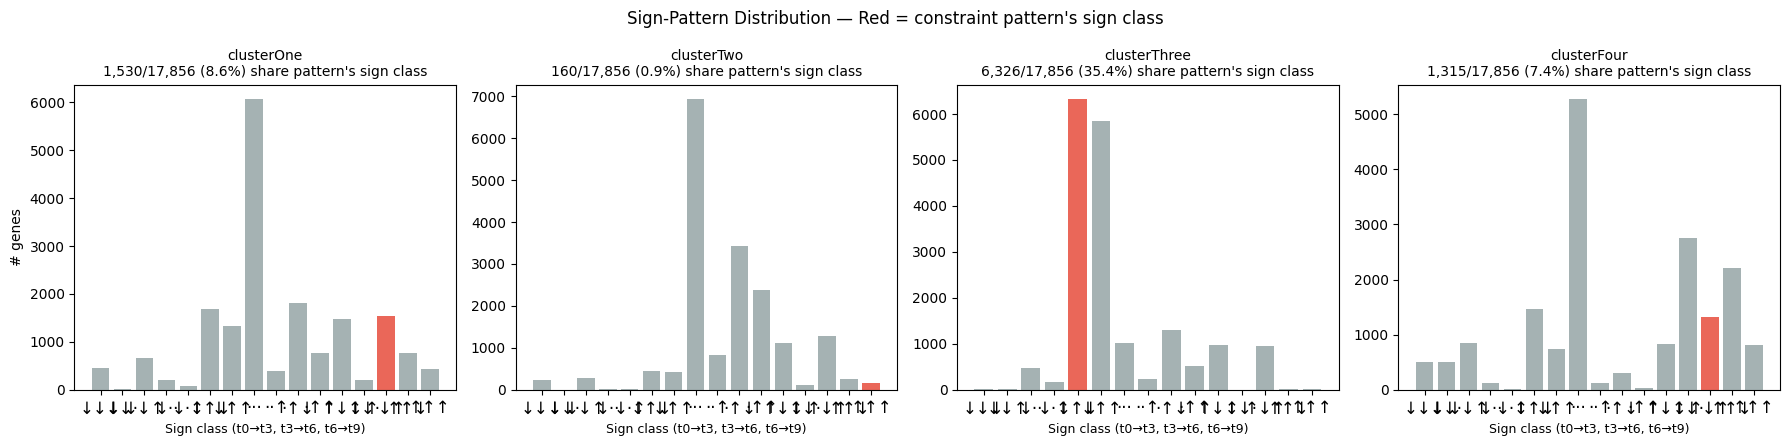

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for idx, cluster_name in enumerate(cluster_names):
    ax = axes[idx]
    counts = sign_counts[cluster_name].sort_index()
    def arrow(p):
        return ''.join(['↑' if s > 0 else '↓' if s < 0 else '·' for s in p])
    labels = [arrow(pat) for pat in counts.index]
    target = pattern_sign[cluster_name]
    colors = ['#e74c3c' if p == target else '#95a5a6' for p in counts.index]
    ax.bar(range(len(counts)), counts.values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, fontsize=12)
    short = cluster_name.replace('LT', '')
    total = int(counts.sum())
    matching = int(counts.get(target, 0))
    ax.set_title(f'{short}\n{matching:,}/{total:,} ({100*matching/total:.1f}%) share pattern\'s sign class', fontsize=10)
    ax.set_xlabel('Sign class (t0→t3, t3→t6, t6→t9)', fontsize=9)
    if idx == 0:
        ax.set_ylabel('# genes')
plt.suptitle('Sign-Pattern Distribution — Red = constraint pattern\'s sign class', fontsize=12)
plt.tight_layout()
plt.savefig('plots/sign_pattern_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.3 Path A — Shape-Based (Gated Ensemble)

Apr 16 landed on **Gate C-norm** = MSE(top-20 centroid, pattern) / (pattern range)². One universal cutoff silences methods whose top-20 centroid is far from the pattern relative to its range. Surviving methods each vote on the top-20; gene rankings are combined by vote count and average rank.

**Optimizes for:** genes moving in the same direction as the pattern, independent of absolute expression level.

**Biological reading:** co-regulation. Genes controlled by the same transcription factor, or part of the same pathway, often share temporal dynamics even when their baseline expression differs by orders of magnitude. This is the assumption behind WGCNA and most co-expression analysis.

In [5]:
# Gate C-norm: relative centroid error
gate_c_norm = pd.DataFrame(index=method_names, columns=cluster_names, dtype=float)
for method_name in method_names:
    for cluster_name in cluster_names:
        top_genes = get_top_genes(method_name, cluster_name, n=20)
        gene_df = gene_dataLT[cluster_name]
        pattern = np.array(constraint_patternsLT[cluster_name]['constraint'], dtype=float)
        valid = [g for g in top_genes if g in gene_df.index]
        centroid = np.mean(gene_df.loc[valid].values, axis=0)
        raw_mse = np.mean((centroid - pattern) ** 2)
        pattern_range = pattern.max() - pattern.min()
        gate_c_norm.loc[method_name, cluster_name] = raw_mse / (pattern_range ** 2 + 1e-10)

thresh = find_gap_threshold(gate_c_norm, ascending=True)
grid = gate_c_norm.astype(float).map(lambda v: '✓' if v <= thresh else '✗')
print(f'Gate C-norm threshold (natural gap): {thresh:.4f}')
print('\nActive methods per cluster:')
print(grid)


Gate C-norm threshold (natural gap): 22.9461

Active methods per cluster:
        clusterOneLT clusterTwoLT clusterThreeLT clusterFourLT
Pearson            ✓            ✓              ✗             ✓
DTW                ✓            ✓              ✗             ✓
Cosine             ✓            ✓              ✗             ✓
Frechet            ✓            ✓              ✗             ✓
MSE                ✓            ✓              ✗             ✓
sMAPE              ✓            ✓              ✓             ✓


In [6]:
# Gated ensemble: only active methods vote
def gated_ensemble(active_grid, n=20):
    results_dict = {}
    for cluster_name in cluster_names:
        active = [m for m in method_names if active_grid.loc[m, cluster_name] == '\u2713']
        if not active:
            results_dict[cluster_name] = pd.DataFrame({'votes': [], 'avg_rank': [], 'active_methods': []})
            continue
        rank_df = pd.DataFrame()
        for mname in active:
            scores, ascending = all_methodsLT[mname]
            s = scores[cluster_name]['constraint']
            rank_df[mname] = s.rank(ascending=ascending, method='min')
        result = pd.DataFrame({
            'votes': (rank_df <= n).sum(axis=1),
            'avg_rank': rank_df.mean(axis=1),
        })
        result = result.sort_values(['votes', 'avg_rank'], ascending=[False, True])
        result['active_methods'] = len(active)
        results_dict[cluster_name] = result
    return results_dict

pathA_results = gated_ensemble(grid)
for cluster_name in cluster_names:
    short = cluster_name.replace('LT', '')
    active = [m for m in method_names if grid.loc[m, cluster_name] == '\u2713']
    top5 = pathA_results[cluster_name].head(5)
    print(f'\n{short} ({len(active)}/6 active: {", ".join(active)}):')
    for gene, row in top5.iterrows():
        print(f'  {gene:<20} votes={int(row["votes"])}/{int(row["active_methods"])}  avg_rank={row["avg_rank"]:.1f}')


clusterOne (6/6 active: Pearson, DTW, Cosine, Frechet, MSE, sMAPE):
  NACA                 votes=5/6  avg_rank=25.5
  AC008875.3           votes=5/6  avg_rank=36.5
  CCDC57               votes=4/6  avg_rank=32.8
  RTRAF                votes=4/6  avg_rank=41.2
  MDFIC                votes=4/6  avg_rank=43.7

clusterTwo (6/6 active: Pearson, DTW, Cosine, Frechet, MSE, sMAPE):
  RAB14                votes=6/6  avg_rank=1.2
  SYNGR1               votes=6/6  avg_rank=2.5
  ARHGAP25             votes=6/6  avg_rank=3.2
  HNRNPH3              votes=6/6  avg_rank=4.8
  BSG                  votes=6/6  avg_rank=5.3

clusterThree (1/6 active: sMAPE):
  AP001372.2           votes=1/1  avg_rank=1.0
  NAB2                 votes=1/1  avg_rank=2.0
  L2HGDH               votes=1/1  avg_rank=3.0
  GPR55                votes=1/1  avg_rank=4.0
  ITIH4                votes=1/1  avg_rank=5.0

clusterFour (6/6 active: Pearson, DTW, Cosine, Frechet, MSE, sMAPE):
  AL139260.1           votes=3/6  avg_rank=2197

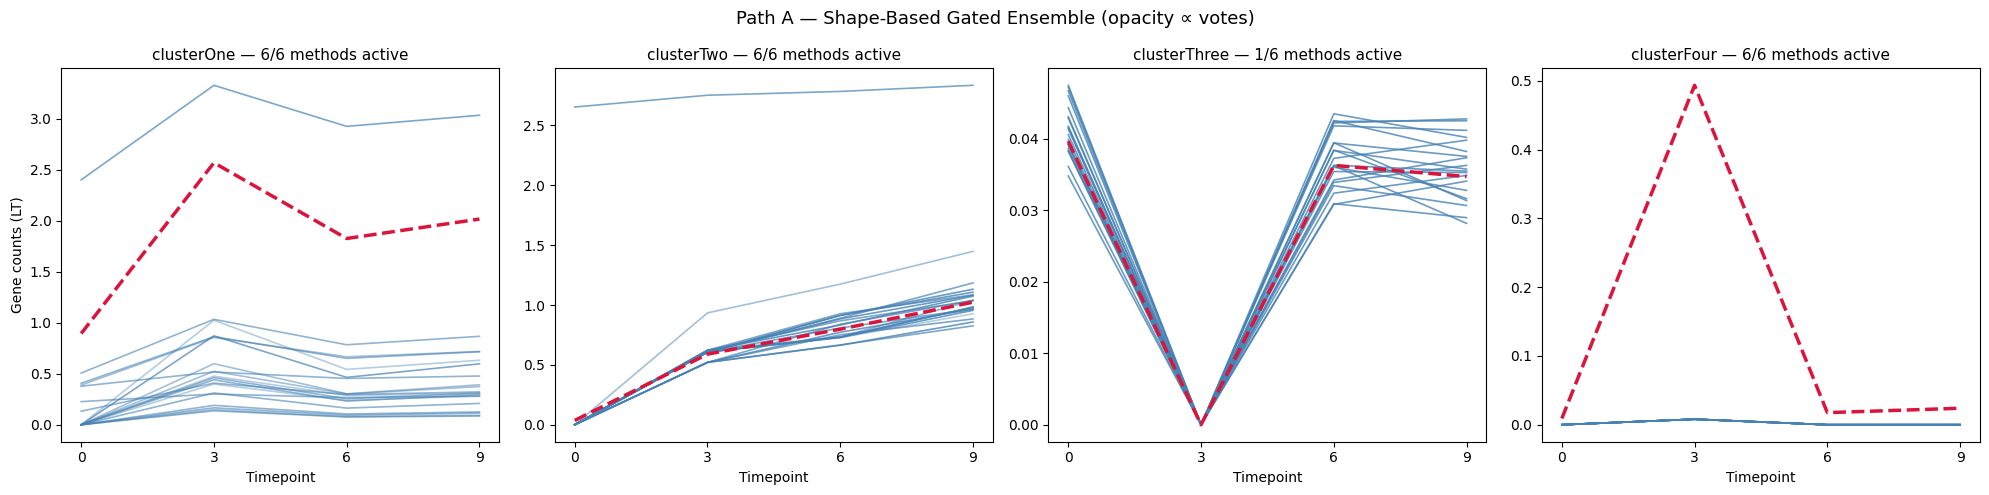

In [7]:
# Plot Path A: gated ensemble top-20 per cluster
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, cluster_name in enumerate(cluster_names):
    ax = axes[idx]
    gene_df = gene_dataLT[cluster_name]
    pattern_vals = constraint_patternsLT[cluster_name]['constraint']
    df = pathA_results[cluster_name]
    active = [m for m in method_names if grid.loc[m, cluster_name] == '\u2713']
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No active methods', transform=ax.transAxes, ha='center', va='center', fontsize=14, color='red')
    else:
        top20 = df.head(20)
        max_v = int(top20['active_methods'].iloc[0])
        for gene, row in top20.iterrows():
            if gene in gene_df.index:
                v = int(row['votes'])
                alpha = 0.2 + 0.6 * (v / max_v) if max_v > 0 else 0.4
                ax.plot(x, gene_df.loc[gene], color='steelblue', alpha=alpha, linewidth=1.2)
        ax.plot(x, pattern_vals, color='crimson', linewidth=2.5, linestyle='--')
    ax.set_xticks(x)
    ax.set_xlabel('Timepoint')
    if idx == 0:
        ax.set_ylabel('Gene counts (LT)')
    short = cluster_name.replace('LT', '')
    ax.set_title(f'{short} \u2014 {len(active)}/6 methods active', fontsize=11)
plt.suptitle('Path A \u2014 Shape-Based Gated Ensemble (opacity \u221d votes)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/pathA_shape_based.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Path B — Magnitude-Based (Raw MAE)

Rank all genes by mean absolute error against the pattern in unnormalized LT expression space. No normalization, no gating.

**Optimizes for:** genes whose absolute expression trajectory is close to the pattern.

**Biological reading:** functional similarity at the quantitative level. If the pattern represents a meaningful expression level (e.g., a signaling threshold, a stoichiometric requirement for a complex), then genes near that level may be more directly comparable in function. Scale matters.

In [8]:
# Raw-space MAE per gene per cluster
raw_mae = {}
for cluster_name in cluster_names:
    pattern = np.array(constraint_patternsLT[cluster_name]['constraint'], dtype=float)
    gene_df = gene_dataLT[cluster_name]
    mae_per_gene = np.mean(np.abs(gene_df.values - pattern), axis=1)
    raw_mae[cluster_name] = pd.Series(mae_per_gene, index=gene_df.index)

for cluster_name in cluster_names:
    short = cluster_name.replace('LT', '')
    top5 = raw_mae[cluster_name].nsmallest(5)
    print(f'\n{short} (best raw-MAE genes):')
    for gene, mae in top5.items():
        print(f'  {gene:<20} MAE={mae:.4f}')


clusterOne (best raw-MAE genes):
  UQCRB                MAE=0.3205
  HSPA8                MAE=0.3208
  EEF2                 MAE=0.3696
  H1FX                 MAE=0.3712
  FXYD5                MAE=0.3714

clusterTwo (best raw-MAE genes):
  SLC2A4RG             MAE=0.0300
  TMEM50A              MAE=0.0336
  CITED2               MAE=0.0369
  ATP8A1               MAE=0.0375
  RAB14                MAE=0.0385

clusterThree (best raw-MAE genes):
  AP001372.2           MAE=0.0004
  NAB2                 MAE=0.0006
  CNTROB               MAE=0.0011
  CTSL                 MAE=0.0011
  GPR55                MAE=0.0013

clusterFour (best raw-MAE genes):
  LINC02446            MAE=0.0157
  SGK1                 MAE=0.0217
  ACTN1                MAE=0.0244
  SESN3                MAE=0.0267
  AFG3L2               MAE=0.0308


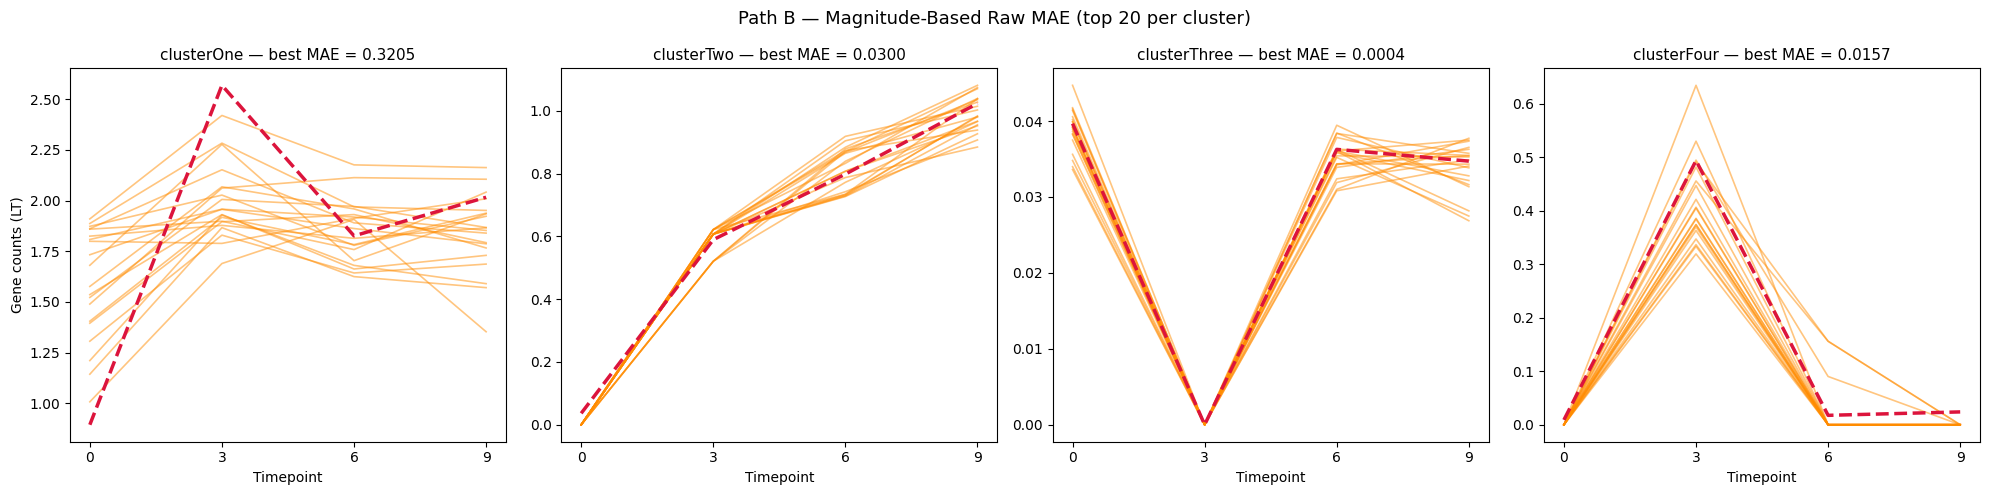

In [9]:
# Plot Path B: raw MAE top-20 per cluster
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, cluster_name in enumerate(cluster_names):
    ax = axes[idx]
    gene_df = gene_dataLT[cluster_name]
    pattern_vals = constraint_patternsLT[cluster_name]['constraint']
    top20 = raw_mae[cluster_name].nsmallest(20)
    for gene in top20.index:
        if gene in gene_df.index:
            ax.plot(x, gene_df.loc[gene], color='darkorange', alpha=0.5, linewidth=1.2)
    ax.plot(x, pattern_vals, color='crimson', linewidth=2.5, linestyle='--')
    ax.set_xticks(x)
    ax.set_xlabel('Timepoint')
    if idx == 0:
        ax.set_ylabel('Gene counts (LT)')
    short = cluster_name.replace('LT', '')
    best = top20.iloc[0]
    ax.set_title(f'{short} \u2014 best MAE = {best:.4f}', fontsize=11)
plt.suptitle('Path B \u2014 Magnitude-Based Raw MAE (top 20 per cluster)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/pathB_magnitude_based.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Side-by-Side Tradeoffs

| Axis | Path A (shape, gated ensemble) | Path B (magnitude, raw MAE) |
|---|---|---|
| Visual fit on plot | Genes at wrong magnitude | Genes sit on the pattern |
| Scale invariance | Yes | No |
| clusterOne handling | Works (spike-shaped genes found at other magnitudes) | Fails (no magnitude match exists) |
| clusterFour handling | Misses the spike (normalization erased it) | Captures it for the first time |
| Overlap with existing NMF consensus | High on clusterTwo | Low on clusterThree / Four |
| Robustness to 4-timepoint problem | Weak — only 8 sign classes | Still meaningful |
| Biological interpretation | Co-regulation, pathway co-membership | Functional similarity at expression level |
| Precedent in literature | WGCNA, Eisen-style hierarchical clustering | Less common for time-series gene expr |

**Open question for the professor:** which interpretation matches the biological question we're trying to answer for this TCR-related pattern?
- If **co-regulation** is the target ("what else is controlled by the same upstream signal?") → Path A.
- If **functional level** is the target ("what else is expressed in a similar quantitative regime?") → Path B.
- If **both** matter → we could intersect the two top-20 lists, or use Path B for clusters where magnitude matches exist (Two/Three/Four) and Path A for clusterOne.

In [10]:
# Path A vs Path B overlap in top-20 per cluster
print(f"{'Cluster':<15}{'Path A \u2229 Path B (top-20)':<30}{'Shared genes'}")
print('-' * 70)
for cluster_name in cluster_names:
    short = cluster_name.replace('LT', '')
    pathA_top = set(pathA_results[cluster_name].head(20).index) if len(pathA_results[cluster_name]) > 0 else set()
    pathB_top = set(raw_mae[cluster_name].nsmallest(20).index)
    overlap = pathA_top & pathB_top
    shared_str = ', '.join(sorted(overlap)) if overlap else '(none)'
    print(f'{short:<15}{len(overlap):>3}/20{"":<22}{shared_str[:100]}')

Cluster        Path A ∩ Path B (top-20)      Shared genes
----------------------------------------------------------------------
clusterOne       0/20                      (none)
clusterTwo      11/20                      ARHGAP25, ATP8A1, CITED2, HNRNPUL1, NOL7, PRDX6, RAB14, RAB5C, SLC2A4RG, SYNGR1, ZC3H15
clusterThree    11/20                      AC017083.1, AF117829.1, AP001372.2, CCDC120, CNTROB, CPPED1, CTSL, GPR55, ITIH4, NAB2, STARD9
clusterFour      0/20                      (none)


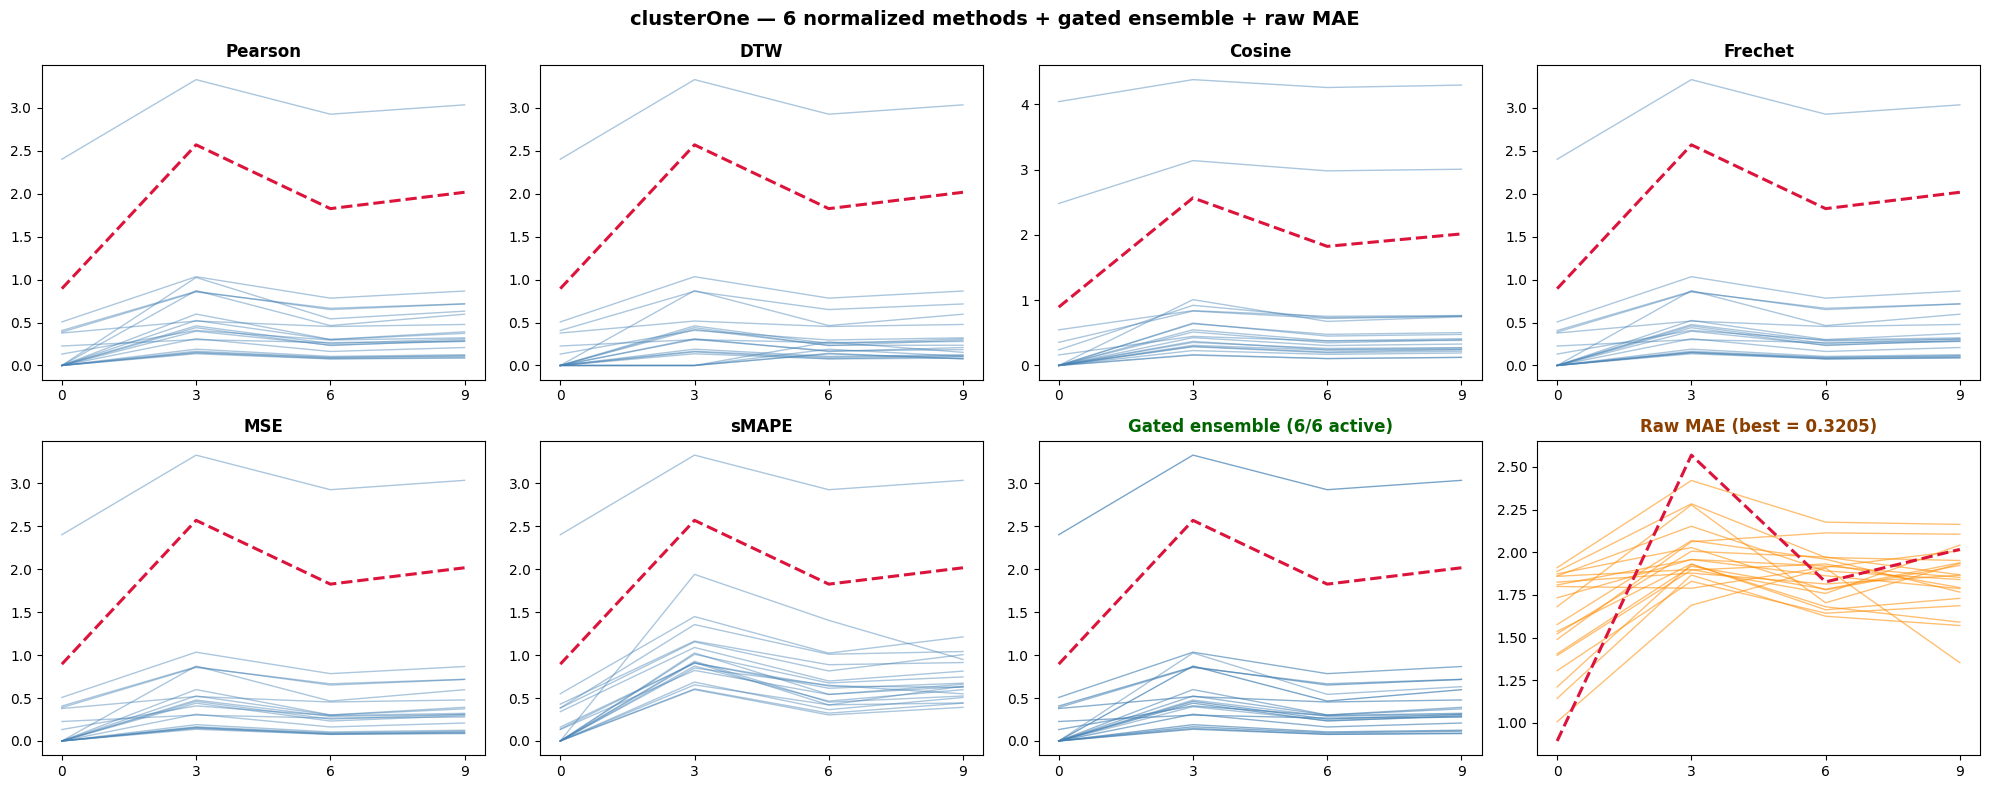

Saved plots/eightways_clusterOne.png


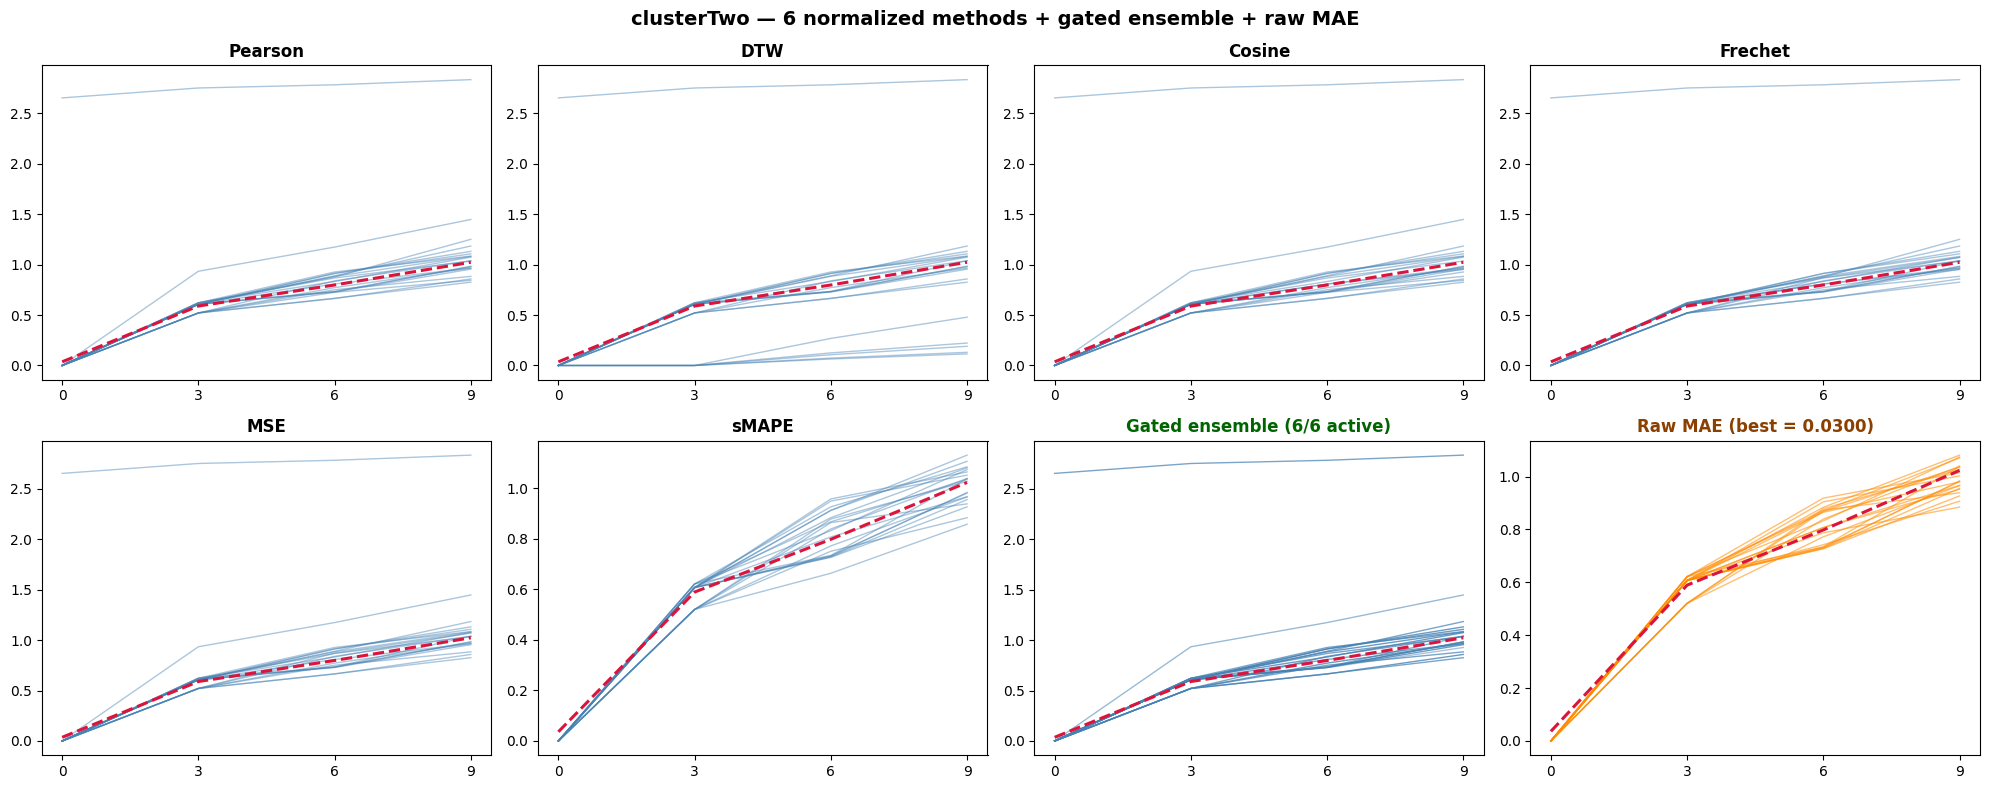

Saved plots/eightways_clusterTwo.png


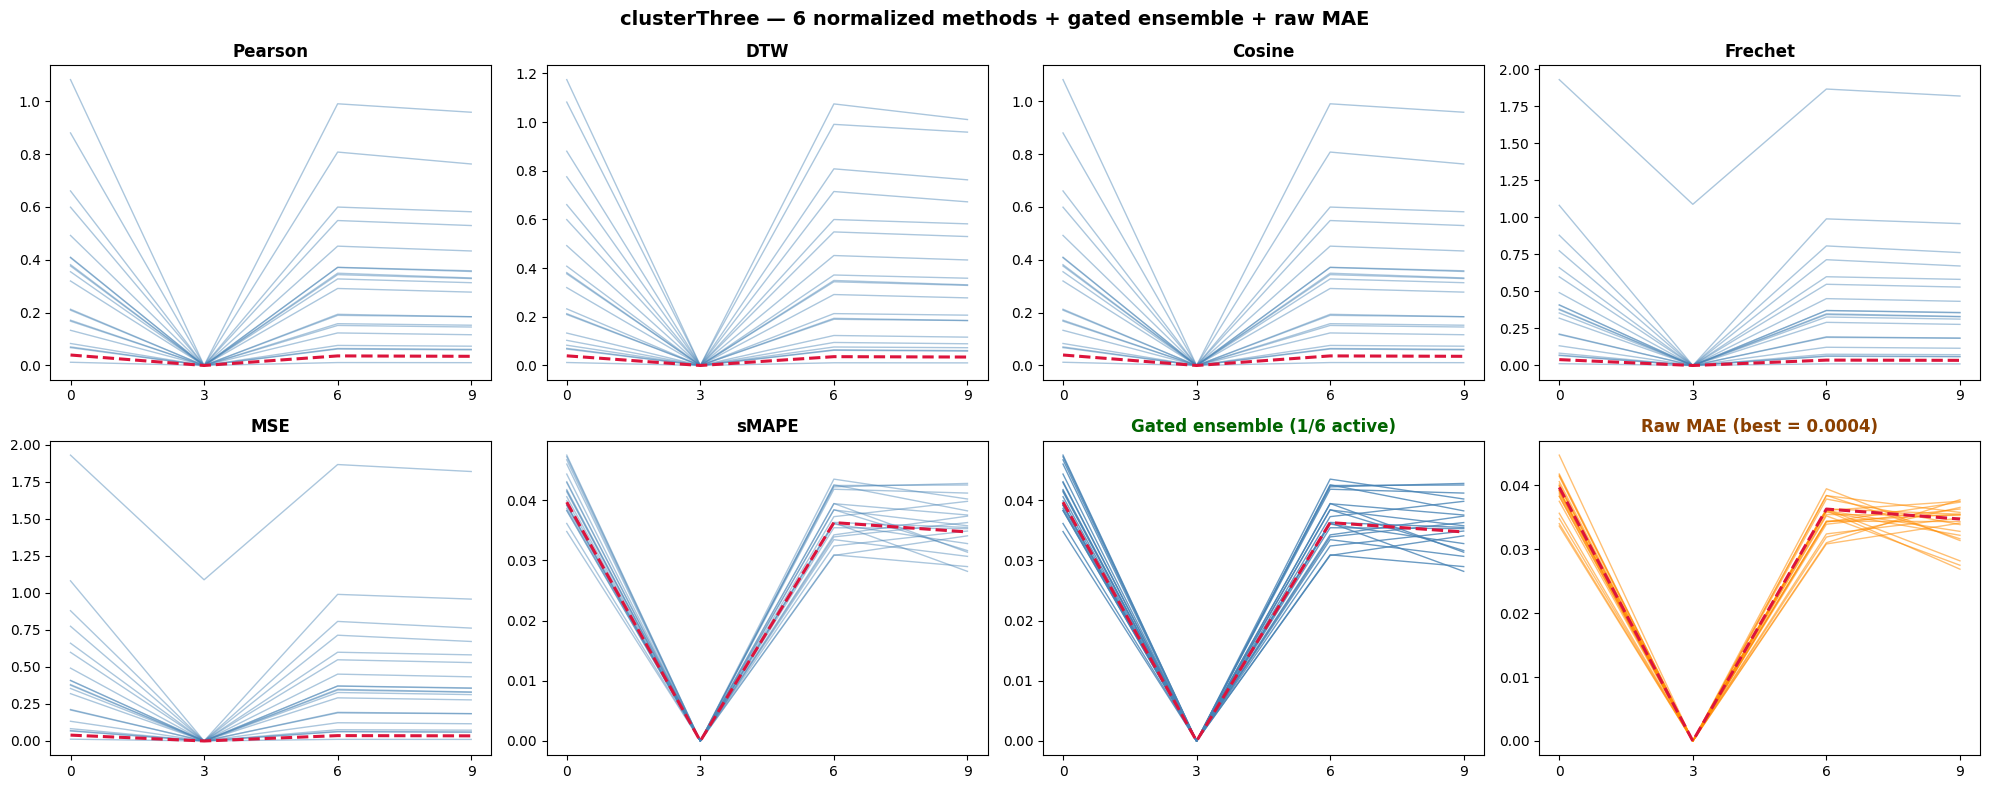

Saved plots/eightways_clusterThree.png


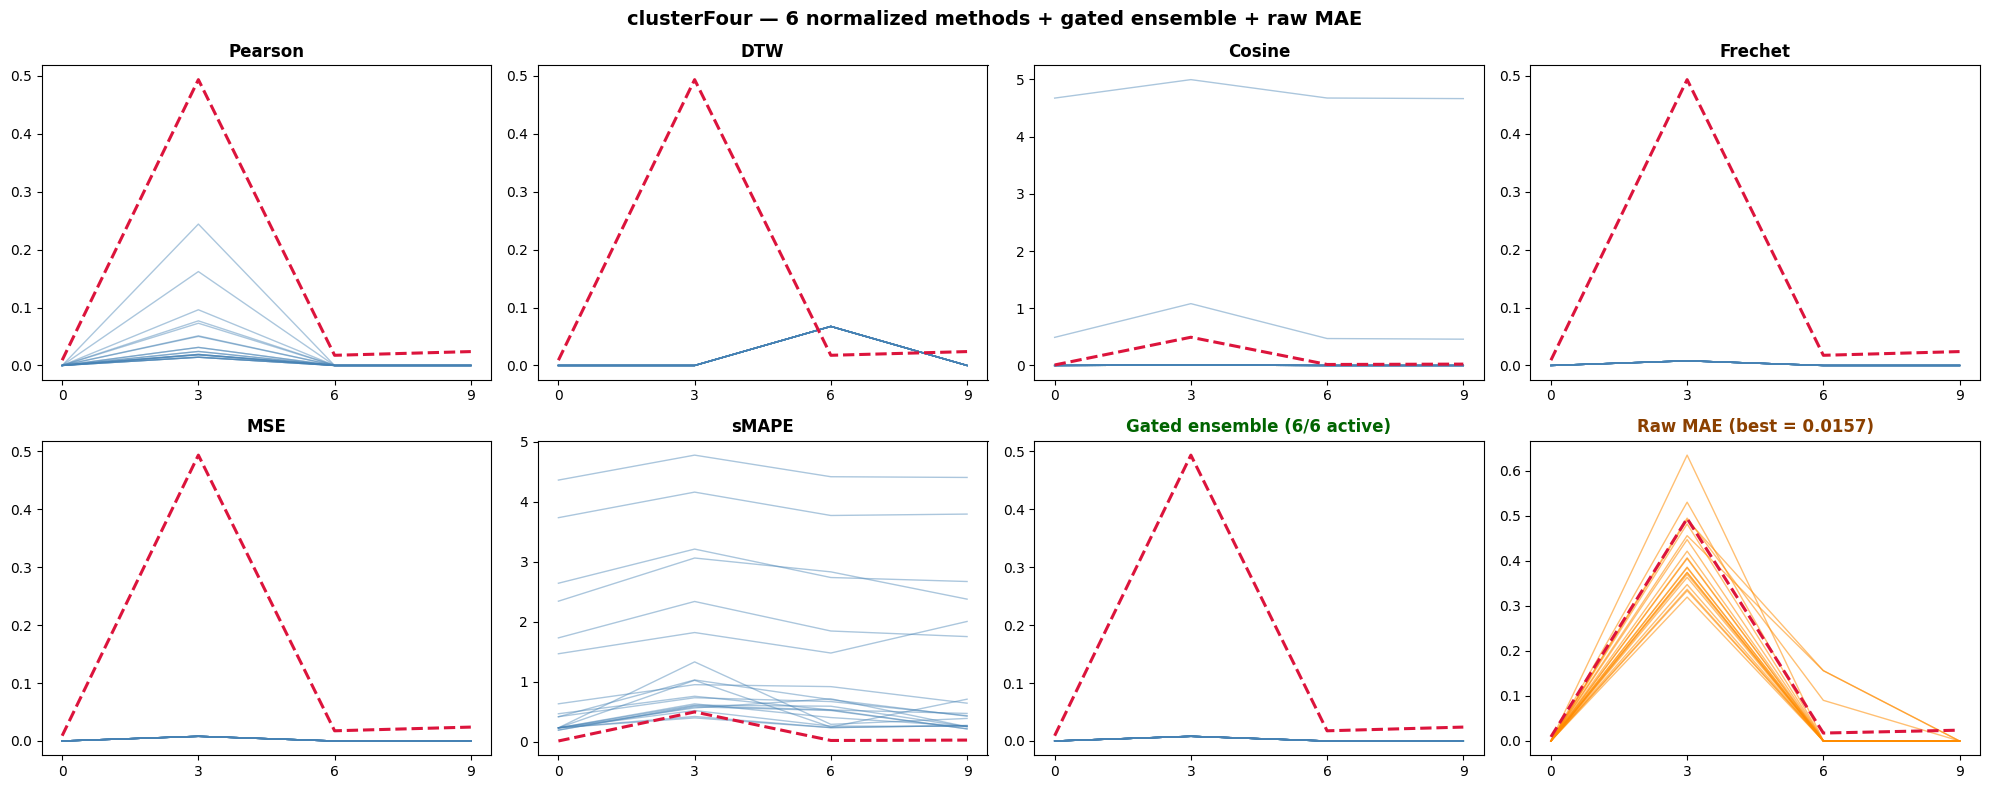

Saved plots/eightways_clusterFour.png


In [11]:
# Per-cluster composite: 6 individual methods + gated ensemble + raw MAE
# One 2x4 grid saved per cluster; used in the slides

for cluster_name in cluster_names:
    short = cluster_name.replace('LT', '')
    gene_df = gene_dataLT[cluster_name]
    pattern_vals = constraint_patternsLT[cluster_name]['constraint']

    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    flat = axes.flatten()

    # Slots 0-5: the 6 original methods
    for i, method_name in enumerate(method_names):
        ax = flat[i]
        top20 = get_top_genes(method_name, cluster_name, n=20)
        for gene in top20:
            if gene in gene_df.index:
                ax.plot(x, gene_df.loc[gene], color='steelblue', alpha=0.45, linewidth=1)
        ax.plot(x, pattern_vals, color='crimson', linewidth=2.2, linestyle='--')
        ax.set_xticks(x)
        ax.set_title(method_name, fontsize=12, fontweight='bold')

    # Slot 6: gated ensemble (Gate C-norm)
    ax = flat[6]
    df_gate = pathA_results[cluster_name]
    active = [m for m in method_names if grid.loc[m, cluster_name] == '✓']
    if len(df_gate) > 0:
        top20_df = df_gate.head(20)
        max_v = int(top20_df['active_methods'].iloc[0])
        for gene, row in top20_df.iterrows():
            if gene in gene_df.index:
                v = int(row['votes'])
                alpha = 0.3 + 0.5 * (v / max_v) if max_v > 0 else 0.4
                ax.plot(x, gene_df.loc[gene], color='steelblue', alpha=alpha, linewidth=1)
    ax.plot(x, pattern_vals, color='crimson', linewidth=2.2, linestyle='--')
    ax.set_xticks(x)
    ax.set_title(f'Gated ensemble ({len(active)}/6 active)', fontsize=12, fontweight='bold', color='#006400')

    # Slot 7: raw-space MAE
    ax = flat[7]
    top20_mae = raw_mae[cluster_name].nsmallest(20)
    for gene in top20_mae.index:
        if gene in gene_df.index:
            ax.plot(x, gene_df.loc[gene], color='darkorange', alpha=0.55, linewidth=1)
    ax.plot(x, pattern_vals, color='crimson', linewidth=2.2, linestyle='--')
    ax.set_xticks(x)
    ax.set_title(f'Raw MAE (best = {top20_mae.iloc[0]:.4f})', fontsize=12, fontweight='bold', color='#8B4000')

    plt.suptitle(f'{short} — 6 normalized methods + gated ensemble + raw MAE', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/eightways_{short}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved plots/eightways_{short}.png')


## 1.6 Literature Touchstones

These ground the tradeoff — they are not tie-breakers, but they show the field has been asking a version of this question for a long time.

1. **Eisen et al. (1998)** — *Cluster analysis and display of genome-wide expression patterns* (PNAS 95:14863). The foundational paper for using Pearson correlation to cluster genes by expression pattern. Explicit argument: **shape** of the expression profile carries biological meaning (co-regulation), independent of absolute level.

2. **Langfelder & Horvath (2008)** — WGCNA R package (BMC Bioinformatics 9:559). Uses absolute Pearson correlation as the co-expression similarity; entire method assumes **scale-invariance** is the right prior for finding co-regulated modules.

3. **Jaskówiak et al. (2014)** — *On the selection of appropriate distances for gene expression data clustering* (BMC Bioinformatics 15 Suppl 2:S2). Comparative study of 15 distance measures; shows **no single distance dominates** — the right choice depends on whether the biological question is about correlated patterns or similar levels.

4. **Liu et al. (2022) — SNMRS** (Computers in Biology and Medicine 141:105090). A hybrid measure that mixes Pearson-like shape agreement with magnitude terms. Makes the case that **pure scale-invariance loses information** in contexts where absolute expression matters.

### What this means for us

- The "shape, not magnitude" view (Eisen, WGCNA) is the default in gene expression analysis. If our goal aligns with co-regulation / module discovery, Path A is the conservative choice.
- The hybrid view (SNMRS and similar recent work) and Jaskówiak's meta-finding both say: the right answer depends on the biological question. If the constraint pattern represents a specific expression level we actually care about matching (not just a shape template), Path B is defensible.
- The 4-timepoint constraint (Sec 1.2) cuts independently: whatever we pick, we should be honest that "shape" at n=4 is 3 bits of directional information. Path A's filtering power is weaker than it would be at n=20.